# Classification: Vision Transformer (ViT)
- Used Pytorch pre trained ViT "vit_base_patch16_224"
- Used same '30kds' as YOLO (same data for training to later compare models)
- ViT expects 224x224px image size
- Runs on gpu/cpu

In [ ]:
# Run 'create_30k_ds.py' to create a balanced distribution (YOLO structure).
# This dataset has 30k real images and 30k fake images
# Split is 80% train, 10% test and 10% valid
# Structure:
'''
30kds/
│── train/
│   ├── Real/   (80% of real images)
│   ├── Fake/   (80% of selected fake images)
│
│── val/
│   ├── Real/   (10% of real images)
│   ├── Fake/   (10% of selected fake images)
│
│── test/
│   ├── Real/   (10% of real images)
│   ├── Fake/   (10% of selected fake images)
'''

In [1]:
import os
import torch
import timm
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import random
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
DATASET_PATH = "30kds"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")

Using device: cuda


In [2]:
# Define Image Transformations (Resize to ViT Input Size)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = ImageFolder(root=TRAIN_PATH, transform=transform)
val_dataset = ImageFolder(root=VAL_PATH, transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [ ]:
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix(loss=f"{running_loss/len(train_loader):.4f}")

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(train_loader):.4f}")

os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/vit_classifier_small.pth")
print("Training complete. Model saved.")

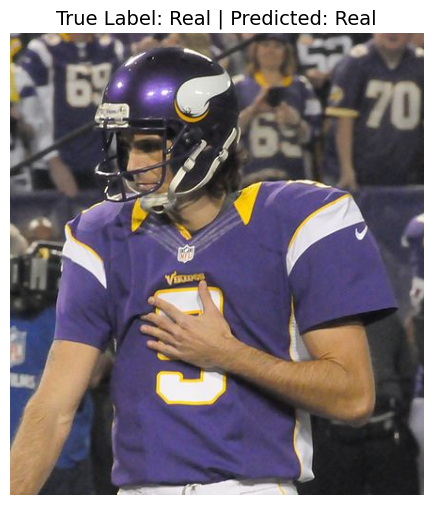

In [3]:
def classify_folder(model_path, folder_path, interval=2):
    """Classifies all images in a folder using a Transformer model and displays predictions."""
    
    # Load the trained Transformer model
    model = timm.create_model("vit_base_patch16_224", num_classes=2)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # Define preprocessing (resize, normalize for ViT)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize for ViT input
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # Get all image files
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(image_files)

    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        img = Image.open(image_path).convert("RGB")  # Open image
        img_tensor = transform(img).unsqueeze(0).to(device)  # Apply preprocessing

        # Run Transformer prediction
        with torch.no_grad():
            output = model(img_tensor)
            predicted_class = torch.argmax(output, dim=1).item()

        class_labels = train_dataset.classes  # Uses correct class order
        predicted_label = class_labels[predicted_class]

        # Extract real label from filename
        real_label = "Unknown"
        for class_name in class_labels:
            if class_name.lower() in image_file.lower():
                real_label = class_name
                break

        # Display the image with prediction
        clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"True Label: {real_label} | Predicted: {predicted_label}", fontsize=14)
        plt.axis("off")
        display(plt.gcf())
        plt.close()

        # Wait before showing the next image
        time.sleep(interval)

# Example usage
classify_folder("models/vit_classifier_small.pth", "class_test")


In [4]:
# Define the validation dataset and DataLoader
val_dataset = ImageFolder(root=VAL_PATH, transform=transform)  # VAL_PATH is the path to your validation folder
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Function to Compute Accuracy
def evaluate_model(model, val_loader, device):
    """Evaluates model accuracy on the validation set."""
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # No gradients needed for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")

# Load Model & Evaluate
model = timm.create_model("vit_base_patch16_224", num_classes=2)
model.load_state_dict(torch.load("models/vit_classifier_small.pth", map_location=device))
model.to(device)
evaluate_model(model, val_loader, device)


Validation Accuracy: 89.09%


With just 10 epochs of training the ViT model achieved a acc of 89%
TODO: 50 epochs